## KNN Classification on Breast Cancer Dataset

This notebook will guide you through implementing the K-Nearest Neighbors (KNN) classification algorithm on the Breast Cancer dataset. We will cover essential machine learning concepts like train-test split, model training, and performance evaluation using various metrics.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

### 1. Loading the Breast Cancer Dataset

The Breast Cancer dataset is a classic dataset for binary classification. It contains features computed from digitized images of fine needle aspirate (FNA) of a breast mass. The goal is to classify whether the mass is malignant (cancerous) or benign (non-cancerous).

In [ ]:
# Load the dataset from scikit-learn.
# `load_breast_cancer()` returns a dictionary-like object.

breast_cancer = load_breast_cancer()


{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

In [10]:
df = pd.DataFrame(
    breast_cancer.data,
    columns = breast_cancer.feature_names
)

df["target"] = breast_cancer.target

df.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


In [11]:
print("Rows and Columns:")

df.shape

Rows and Columns:


(569, 31)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [13]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [14]:
missing_values = df.isnull().sum()

print(missing_values)

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [15]:
duplicate_count = df.duplicated().sum()

print("Duplicate Records:", duplicate_count)

Duplicate Records: 0


In [16]:
X = df.drop(
    "target",
    axis=1
)

y = df["target"]


print(X.shape)

print(y.shape)

(569, 30)
(569,)


In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


Feature scaling is necessary for KNN because KNN calculates distances between data points. Large-valued features can dominate smaller features. StandardScaler converts all features to the same scale.

### 2. Splitting Data into Training and Testing Sets

Before training any model, it's crucial to split your data into two parts: a **training set** and a **testing set**.

*   The **training set** is used to teach the model how to make predictions.
*   The **testing set** is used to evaluate how well the model performs on unseen data. This helps us to check if the model is truly learning and not just memorizing the training data (overfitting).

We typically use a `train_test_split` function, common splits are 70/30 or 80/20 for training/testing.

In [18]:
# We'll split 80% of the data for training and 20% for testing.
# `random_state` ensures that our split is the same every time we run the code.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train (training features):", X_train.shape)
print("Shape of X_test (testing features):", X_test.shape)
print("Shape of y_train (training target):", y_train.shape)
print("Shape of y_test (testing target):", y_test.shape)

Shape of X_train (training features): (455, 30)
Shape of X_test (testing features): (114, 30)
Shape of y_train (training target): (455,)
Shape of y_test (testing target): (114,)


In [19]:
#Train KNN for 80:20
knn = KNeighborsClassifier(
    n_neighbors=5
)


knn.fit(
    X_train,
    y_train
)


y_pred = knn.predict(
    X_test
)


accuracy_80 = accuracy_score(
    y_test,
    y_pred
)


print("80:20 Accuracy:", accuracy_80)

80:20 Accuracy: 0.956140350877193


In [20]:
split_results = {}

splits = {
    "70:30":0.3,
    "80:20":0.2,
    "90:10":0.1
}

for name,size in splits.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,
        y,
        test_size=size,
        random_state=42
    )
    model = KNeighborsClassifier(
        n_neighbors=5
    )

    model.fit(
        X_train,
        y_train
    )
    pred = model.predict(
        X_test
    )


    split_results[name] = accuracy_score(
        y_test,
        pred
    )
split_results

{'70:30': 0.9590643274853801,
 '80:20': 0.9473684210526315,
 '90:10': 0.9298245614035088}

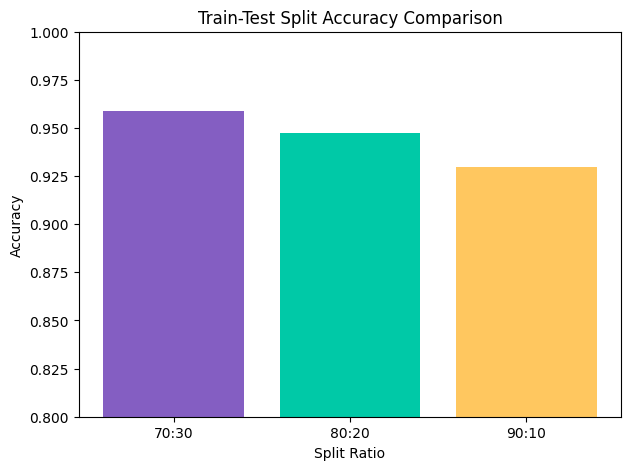

In [21]:
plt.figure(figsize=(7,5))
plt.bar(
    split_results.keys(),
    split_results.values(),
    color=[
        "#845EC2",
        "#00C9A7",
        "#FFC75F"
    ]
)
plt.title(
    "Train-Test Split Accuracy Comparison"
)
plt.xlabel(
    "Split Ratio"
)
plt.ylabel(
    "Accuracy"
)
plt.ylim(
    0.8,
    1
)
plt.show()

The accuracy changes slightly for different train-test splits because the amount of training and testing data changes. A balanced split provides better estimation of model performance.

### 3. Heuristic K Selection for KNN

In KNN, 'K' is the number of nearest neighbors considered when making a prediction. Choosing a good 'K' is important.

A simple heuristic (rule of thumb) for choosing 'K' is to take the square root of the total number of samples in your training data. If the result is an even number, it's often good practice to pick an odd number to avoid ties in classification (e.g., if K=2, and one neighbor is class A and one is class B, it's a tie). Let's calculate a `K` value based on this heuristic.

In [27]:
import math
n = len(X_train)
heuristic_k = int(
    math.sqrt(n)
)
# Make K odd to avoid voting ties
if heuristic_k % 2 == 0:
    heuristic_k += 1

print("Number of training samples:", n)
print("Heuristic K value:", heuristic_k)

Number of training samples: 512
Heuristic K value: 23


In [28]:
#Model Training using Heuristic K
knn_heuristic = KNeighborsClassifier(
    n_neighbors = heuristic_k
)


knn_heuristic.fit(
    X_train,
    y_train
)


heuristic_prediction = knn_heuristic.predict(
    X_test
)


heuristic_accuracy = accuracy_score(
    y_test,
    heuristic_prediction
)


print(
    "Accuracy using heuristic K:",
    heuristic_accuracy
)

Accuracy using heuristic K: 0.9298245614035088


The KNN model is trained using the K value obtained from the √n heuristic method. This provides a baseline performance before tuning K values.

In [29]:
k_values = range(
    heuristic_k - 5,
    heuristic_k + 6
)


accuracy_values = []


for k in k_values:


    model = KNeighborsClassifier(
        n_neighbors = k
    )


    model.fit(
        X_train,
        y_train
    )


    prediction = model.predict(
        X_test
    )


    accuracy = accuracy_score(
        y_test,
        prediction
    )


    accuracy_values.append(
        accuracy
    )


for k,acc in zip(k_values,accuracy_values):

    print(
        "K =",k,
        "Accuracy =",acc
    )

K = 18 Accuracy = 0.9473684210526315
K = 19 Accuracy = 0.9473684210526315
K = 20 Accuracy = 0.9473684210526315
K = 21 Accuracy = 0.9298245614035088
K = 22 Accuracy = 0.9473684210526315
K = 23 Accuracy = 0.9298245614035088
K = 24 Accuracy = 0.9298245614035088
K = 25 Accuracy = 0.9473684210526315
K = 26 Accuracy = 0.9298245614035088
K = 27 Accuracy = 0.9473684210526315
K = 28 Accuracy = 0.9298245614035088


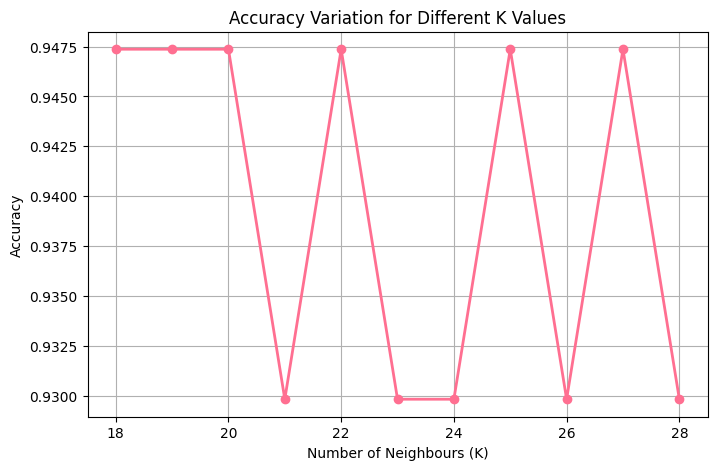

In [30]:
# Accuracy vs K Graph
plt.figure(
    figsize=(8,5)
)
plt.plot(
    k_values,
    accuracy_values,
    marker="o",
    linewidth=2,
    color="#FF6F91"
)
plt.title(
    "Accuracy Variation for Different K Values"
)
plt.xlabel(
    "Number of Neighbours (K)"
)
plt.ylabel(
    "Accuracy"
)
plt.grid(
    True
)
plt.show()

The graph shows how changing K affects model performance. Lower K values make the model sensitive to noise, while higher K values create smoother decisions. The K value giving the highest accuracy is selected as optimal.

In [31]:
optimal_k = list(k_values)[
    accuracy_values.index(
        max(accuracy_values)
    )
]


print(
    "Optimal K value:",
    optimal_k
)


print(
    "Maximum Accuracy:",
    max(accuracy_values)
)

Optimal K value: 18
Maximum Accuracy: 0.9473684210526315


The optimal K is selected based on the highest testing accuracy obtained from nearby K values.

Euclidean Distance:

Euclidean distance calculates the straight line distance between two points.

Formula:
d = √((x2-x1)² + (y2-y1)²)

It is suitable for continuous numerical data where features are properly scaled.


Manhattan Distance:

Manhattan distance calculates distance by adding the absolute difference between feature values.

Formula:
d = |x2-x1| + |y2-y1|

It is suitable for high-dimensional data and grid-like movement problems.

In [32]:
# Decision Boundary Mapping
from sklearn.decomposition import PCA


pca = PCA(
    n_components = 2
)


X_pca = pca.fit_transform(
    X_scaled
)


print(
    X_pca.shape
)

(569, 2)


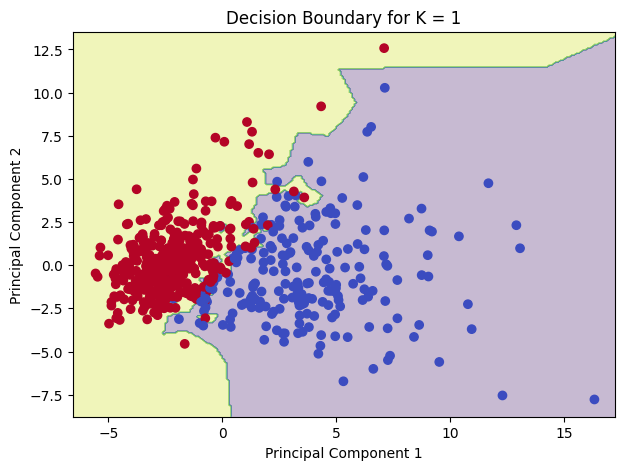

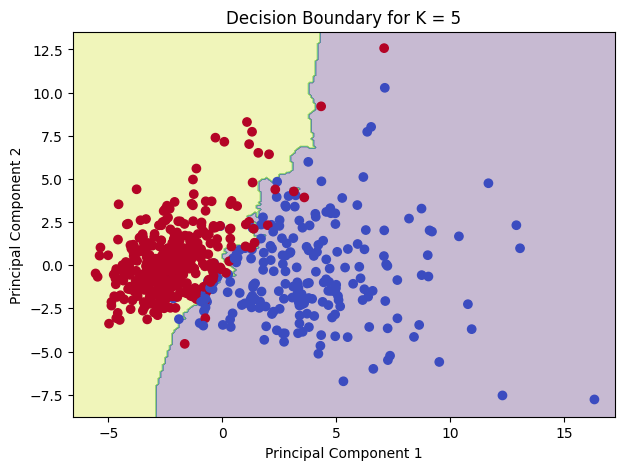

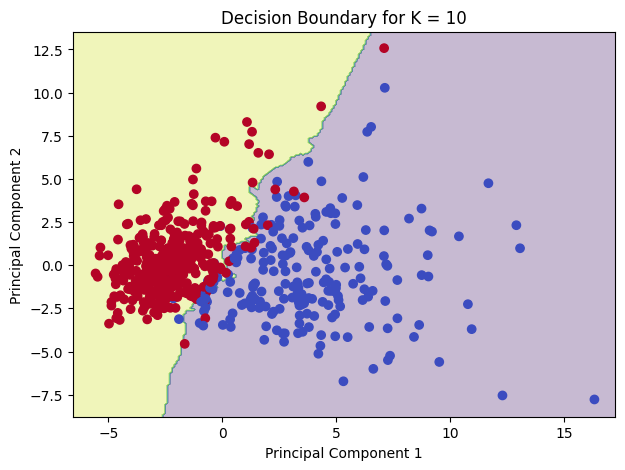

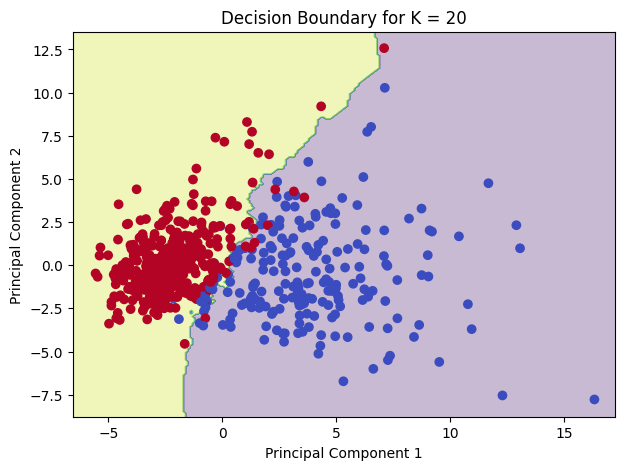

In [33]:
k_boundary = [
    1,
    5,
    10,
    20
]


colors = [
    "#845EC2",
    "#00C9A7",
    "#FF9671",
    "#0081CF"
]


for index,k in enumerate(k_boundary):


    model = KNeighborsClassifier(
        n_neighbors = k
    )


    model.fit(
        X_pca,
        y
    )


    x_min = X_pca[:,0].min() - 1
    x_max = X_pca[:,0].max() + 1


    y_min = X_pca[:,1].min() - 1
    y_max = X_pca[:,1].max() + 1



    xx,yy = np.meshgrid(

        np.arange(
            x_min,
            x_max,
            0.1
        ),


        np.arange(
            y_min,
            y_max,
            0.1
        )
    )



    Z = model.predict(
        np.c_[
            xx.ravel(),
            yy.ravel()
        ]
    )


    Z = Z.reshape(
        xx.shape
    )



    plt.figure(
        figsize=(7,5)
    )


    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )



    plt.scatter(
        X_pca[:,0],
        X_pca[:,1],
        c=y,
        cmap="coolwarm"
    )


    plt.title(
        "Decision Boundary for K = " + str(k)
    )


    plt.xlabel(
        "Principal Component 1"
    )


    plt.ylabel(
        "Principal Component 2"
    )


    plt.show()

For K = 1, the decision boundary is highly irregular because the model memorizes individual points and may overfit.

For K = 5 and K = 10, the boundary becomes smoother and provides better generalization.

For K = 20, the model becomes very simple. Very large K values can increase bias and reduce the ability to detect local patterns.

### 4. Cross Validation

Now we will initialize our KNN classifier with the chosen `K` value and train it using our training data.

*   `n_neighbors` is the K value.
*   `fit(X_train, y_train)` is where the model 'learns' by storing the training data.

In [36]:
from sklearn.model_selection import cross_val_score


cv_accuracy = {}


for k in range(1,31):


    model = KNeighborsClassifier(
        n_neighbors = k
    )


    scores = cross_val_score(
        model,
        X_scaled,
        y,
        cv = 5,
        scoring = "accuracy"
    )


    cv_accuracy[k] = scores.mean()



for k,value in cv_accuracy.items():

    print(
        "K =",
        k,
        "Mean Accuracy =",
        value
    )

K = 1 Mean Accuracy = 0.9507685142058687
K = 2 Mean Accuracy = 0.9419189566837447
K = 3 Mean Accuracy = 0.9577705325260053
K = 4 Mean Accuracy = 0.9612793044558299
K = 5 Mean Accuracy = 0.9648501785437045
K = 6 Mean Accuracy = 0.9630802670392795
K = 7 Mean Accuracy = 0.9683589504735289
K = 8 Mean Accuracy = 0.9683434249340165
K = 9 Mean Accuracy = 0.968390001552554
K = 10 Mean Accuracy = 0.9648657040832168
K = 11 Mean Accuracy = 0.9631113181183046
K = 12 Mean Accuracy = 0.9648657040832168
K = 13 Mean Accuracy = 0.9648812296227295
K = 14 Mean Accuracy = 0.9666356155876417
K = 15 Mean Accuracy = 0.9613569321533924
K = 16 Mean Accuracy = 0.9648657040832168
K = 17 Mean Accuracy = 0.9578326346840551
K = 18 Mean Accuracy = 0.9578326346840551
K = 19 Mean Accuracy = 0.9543238627542309
K = 20 Mean Accuracy = 0.952585002328831
K = 21 Mean Accuracy = 0.9525694767893185
K = 22 Mean Accuracy = 0.9543393882937432
K = 23 Mean Accuracy = 0.9543393882937432
K = 24 Mean Accuracy = 0.9560937742586555
K =

K-Fold Cross Validation divides the dataset into multiple parts. The model is trained and tested several times using different data portions. It gives a more reliable performance estimate than a single train-test split.

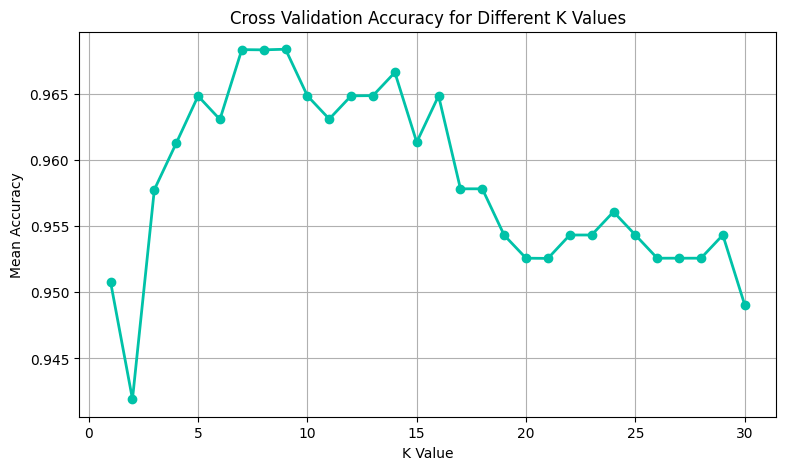

In [37]:
plt.figure(
    figsize=(9,5)
)


plt.plot(
    list(cv_accuracy.keys()),
    list(cv_accuracy.values()),
    marker="o",
    color="#00C2A8",
    linewidth=2
)


plt.title(
    "Cross Validation Accuracy for Different K Values"
)


plt.xlabel(
    "K Value"
)


plt.ylabel(
    "Mean Accuracy"
)


plt.grid(True)


plt.show()

The graph compares different K values using cross-validation. The K value with the highest average accuracy provides the best balance between underfitting and overfitting.

In [38]:
best_k = max(
    cv_accuracy,
    key = cv_accuracy.get
)


print(
    "Best K from Cross Validation:",
    best_k
)


print(
    "Best Cross Validation Accuracy:",
    cv_accuracy[best_k]
)

Best K from Cross Validation: 9
Best Cross Validation Accuracy: 0.968390001552554


### 5. Classification Evaluation

For classification tasks, we use specific metrics to understand how well our model is performing. Unlike regression metrics (like Mean Squared Error), classification metrics focus on how many predictions were correct or incorrect, and what kind of errors were made.

*   **Accuracy**: The proportion of total correct predictions (both positive and negative) out of all predictions.
*   **Precision**: Out of all predicted positive cases, how many were actually positive? (Minimizes false positives).
*   **Recall (Sensitivity)**: Out of all actual positive cases, how many did the model correctly identify? (Minimizes false negatives).
*   **F1-Score**: The harmonic mean of Precision and Recall. It's a good measure when you need to balance both precision and recall, especially with imbalanced classes.

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


final_knn = KNeighborsClassifier(
    n_neighbors = best_k
)


X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y,
    test_size = 0.2,
    random_state = 42
)



final_knn.fit(
    X_train,
    y_train
)



final_prediction = final_knn.predict(
    X_test
)

In [40]:
accuracy = accuracy_score(
    y_test,
    final_prediction
)


precision = precision_score(
    y_test,
    final_prediction
)


recall = recall_score(
    y_test,
    final_prediction
)


f1 = f1_score(
    y_test,
    final_prediction
)



print(
    "Accuracy:",
    accuracy
)


print(
    "Precision:",
    precision
)


print(
    "Recall:",
    recall
)


print(
    "F1 Score:",
    f1
)

Accuracy: 0.9649122807017544
Precision: 0.971830985915493
Recall: 0.971830985915493
F1 Score: 0.971830985915493


Accuracy shows overall correct predictions.

Precision shows how many predicted benign cases were actually correct.

Recall shows how many actual cases were correctly detected.

F1 score balances precision and recall.

In medical diagnosis, recall is very important because missing a cancer case can have serious consequences.

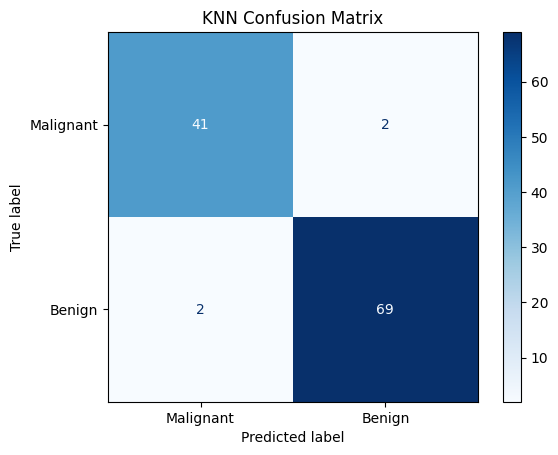

In [41]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


matrix = confusion_matrix(
    y_test,
    final_prediction
)


display = ConfusionMatrixDisplay(
    confusion_matrix = matrix,
    display_labels = [
        "Malignant",
        "Benign"
    ]
)



display.plot(
    cmap = "Blues"
)


plt.title(
    "KNN Confusion Matrix"
)


plt.show()

The confusion matrix displays correct and incorrect classifications.

It shows:

True Positive cases

True Negative cases

False Positive cases

False Negative cases

False negatives are dangerous in cancer prediction because a patient with cancer may be classified as healthy.

In [42]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc


probability = final_knn.predict_proba(
    X_test
)[:,1]



fpr, tpr, threshold = roc_curve(
    y_test,
    probability
)



auc_score = auc(
    fpr,
    tpr
)



print(
    "AUC Score:",
    auc_score
)

AUC Score: 0.9810022928267277


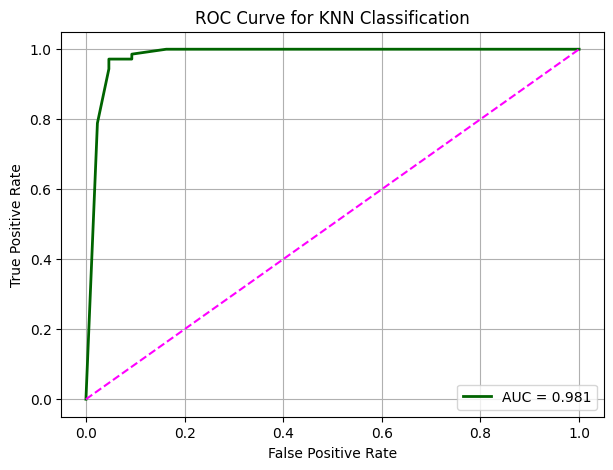

In [46]:
plt.figure(
    figsize=(7,5)
)


plt.plot(
    fpr,
    tpr,
    color="darkgreen",
    linewidth=2,
    label="AUC = "+str(round(auc_score,3))
)



plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="magenta"
)


plt.title(
    "ROC Curve for KNN Classification"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.legend()


plt.grid(True)


plt.show()

The ROC curve shows the ability of the KNN model to separate malignant and benign classes. A higher AUC value indicates better classification performance.

### 6. Comparison between Regression and Classification Evaluation Metrics

Regression Evaluation:

Regression models predict continuous numerical values.

Examples:
- House price prediction
- Temperature prediction
- Sales forecasting

Evaluation metrics used:

1. MAE (Mean Absolute Error):
Measures the average absolute difference between actual and predicted values.

2. MSE (Mean Squared Error):
Calculates the average squared difference between actual and predicted values.

3. RMSE (Root Mean Squared Error):
Measures prediction error magnitude in the same unit as the target variable.

4. R² Score:
Measures how well the regression model explains the variation in the target variable.



Classification Evaluation:

Classification models predict discrete class labels.

Examples:
- Cancer prediction
- Spam detection
- Disease classification


Evaluation metrics used:

1. Accuracy:
Measures the percentage of correct predictions.

2. Precision:
Measures correctness among positive predictions.

3. Recall:
Measures how many actual positive cases are correctly detected.

4. F1 Score:
Combines precision and recall into a single metric.

5. Confusion Matrix:
Shows correct and incorrect classifications.

6. ROC-AUC:
Measures the ability of a classifier to distinguish between classes.

### Error Based Evaluation (Regression):

Regression evaluation measures how far predicted numerical values are from actual values.

Metrics such as MAE, MSE and RMSE calculate the size of prediction errors.

A smaller error value represents better model performance.


Decision Based Evaluation (Classification):

Classification evaluation measures whether the predicted class decision is correct or incorrect.

Metrics such as Accuracy, Precision, Recall and F1 Score analyze classification quality.

The focus is not the size of error but the correctness of the predicted category.

### R² Score vs Accuracy:

R² Score:

- Used in regression problems.
- Measures how well independent variables explain the dependent variable.
- Value closer to 1 indicates better regression performance.


Accuracy:

- Used in classification problems.
- Measures the ratio of correct predictions among total predictions.
- Higher accuracy means more correct classifications.

### RMSE vs F1 Score:

RMSE:

- Regression metric.
- Calculates average prediction error magnitude.
- Lower RMSE means better prediction accuracy.


F1 Score:

- Classification metric.
- Harmonic mean of Precision and Recall.
- Useful when classes are imbalanced.
- Higher F1 score indicates better classification performance.

### MAE vs Confusion Matrix:


MAE:

- Used for continuous predictions.
- Measures average absolute prediction error.
- Shows how much the predicted value differs from actual value.


Confusion Matrix:

- Used for classification.
- Displays correct and incorrect predictions.
- Shows True Positive, True Negative, False Positive and False Negative results.

Continuous Prediction Tasks:

- Output is a numerical value.
- Evaluation focuses on reducing prediction error.
- Regression metrics are used.


Classification Tasks:

- Output is a category/class.
- Evaluation focuses on correct decision making.
- Classification metrics are used.

### Inference:

Regression metrics measure prediction error magnitude by calculating the difference between actual and predicted continuous values.

Classification metrics measure decision correctness by checking whether predicted class labels match actual classes.

Accuracy alone is insufficient in medical diagnosis because datasets may be imbalanced and incorrect predictions can have serious effects.

Recall is more important in healthcare because it reduces false negative cases, ensuring patients with disease are correctly identified.

ROC-AUC is useful because it measures the ability of the model to separate positive and negative classes across different thresholds.

Overall, regression evaluation focuses on minimizing numerical errors, while classification evaluation focuses on improving decision accuracy and class identification.

### 7. Analytical Questions.

1. Why is KNN called a lazy learning algorithm?

KNN is called lazy learning because it does not create a model during training. It stores the training data and performs calculations only when a new prediction is required.



2. Why is feature scaling required in KNN?

KNN uses distance calculations. Without scaling, features with larger values dominate the distance measurement and affect prediction accuracy.



3. Explain heuristic K selection using √n rule.

The √n rule selects K by calculating the square root of the number of training samples.

K = √n

It provides a good starting value for selecting neighbours.



4. Why is cross-validation more reliable than a single train-test split?

Cross-validation evaluates the model using multiple training and testing combinations.

It reduces dependency on one random split and gives more stable performance measurement.



5. How does K affect bias-variance trade-off?

Small K:
- Low bias
- High variance
- Can cause overfitting


Large K:
- High bias
- Low variance
- Can cause underfitting



6. Why is recall more important than accuracy in cancer prediction?

Recall is important because it focuses on detecting actual cancer patients.

A false negative result can classify a cancer patient as healthy, which is dangerous.



7. What is the limitation of very large K values?

Very large K values make the model too simple.

The classifier may ignore local patterns and cause underfitting.

### Conclusion:

In this experiment, K-Nearest Neighbour classification was implemented using the Breast Cancer Wisconsin dataset.

The initial K value was selected using the √n heuristic method and further improved using different K values and cross-validation.

Different train-test splits showed that model performance changes depending on the amount of training and testing data.

Cross-validation provided a more reliable method for selecting the optimal K value.

The final KNN model was evaluated using Accuracy, Precision, Recall, F1 Score, Confusion Matrix and ROC-AUC score.

For healthcare prediction, Recall and ROC-AUC are more important because correctly identifying cancer cases is critical.

Compared with Linear Regression from Lab 3, regression metrics measure numerical prediction errors while classification metrics measure correctness of class decisions.

This experiment demonstrates the difference between regression evaluation frameworks and classification evaluation frameworks.